# Contrail mitigation variants for the ATAG scenarios

The *Waypoint 2050* reports leave contrail mitigation out entirely — every
scenario runs with `operations_contrails_start_year = 2101`, which switches the
lever off. Contrails are nonetheless the largest single warming term in these
scenarios: **46.1 mK of the 87.7 mK** total in 2050 for third-edition S1, more
than CO₂'s 34.0 mK. This notebook quantifies what that omission costs.

The variants are parameterised on **Teoh et al. (2020)**, *Mitigating the
Climate Forcing of Aircraft Contrails by Small-Scale Diversions and Technology
Adoption*, Environ. Sci. Technol., [doi:10.1021/acs.est.9b05608](https://doi.org/10.1021/acs.est.9b05608),
which reports reductions in contrail energy forcing for three interventions.
Three families × {Low, Central, High} = nine variants, all branched from
third-edition S1; the parameter values and the reasoning behind
them live in `contrail_variants.yaml`.

No model code was changed. AeroMAPS already carries this paper's small-scale
case as its defaults (`operations_contrails_final_gain = 59.4`,
`operations_contrails_final_overconsumption = 0.014`), and
`OperationsContrailsSimple` is already active in these scenarios — only the
start year kept it dormant.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utils
from utils import LEVELS, load_contrail_variants, variant_name

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

from aeromaps import assemble_processes, create_process

BASELINE = "No mitigation (as reported)"

reference, families = load_contrail_variants()
print(f"source: {reference['citation'].strip()}")
print(f"doi   : {reference['doi']}\n")
for key, family in families.items():
    gains = [family["levels"][lvl]["operations_contrails_final_gain"] for lvl in LEVELS]
    start = family["levels"]["Central"]["operations_contrails_start_year"]
    print(f"  {family['label']:<34} from {start}  gain {gains} %")

source: Teoh et al. (2020), Mitigating the Climate Forcing of Aircraft Contrails by Small-Scale Diversions and Technology Adoption, Environ. Sci. Technol.
doi   : 10.1021/acs.est.9b05608

  Low-risk diversion                 from 2030  gain [17.4, 20.0, 23.0] %
  Small-scale diversion              from 2030  gain [52.4, 59.3, 65.6] %
  Long-term combustor technology     from 2035  gain [45.2, 68.8, 82.1] %


## Build and run the twelve variants

Each variant is the unmodified third-edition S1 configuration with four
parameter overrides. The baseline is the same configuration untouched, so any
difference is attributable to the contrail lever alone.

In [2]:
cwd = os.getcwd()
os.chdir(utils.BASE / "3rd_edition_full")
try:
    processes = {BASELINE: create_process("./config_files/config_s1.yaml")}
    for key, family in families.items():
        for level in LEVELS:
            process = create_process("./config_files/config_s1.yaml")
            for parameter, value in family["levels"][level].items():
                setattr(process.parameters, parameter, value)
            processes[variant_name(family["label"], level)] = process

    assembly = assemble_processes(processes)
    assembly.compute_all()
finally:
    os.chdir(cwd)

# Only the families are declared as groups. The baseline is left ungrouped, so
# _iter_scenario_groups yields it as a singleton and it is drawn as a plain
# reference line rather than a degenerate one-member envelope.
groups = {
    family["label"]: [variant_name(family["label"], lvl) for lvl in LEVELS]
    for family in families.values()
}

print(f"{len(processes)} scenarios computed "
      f"({len(processes) - 1} variants + baseline), in {len(groups)} groups")

# Pin the Central variant as each envelope's middle line. With three members the
# pointwise median already resolves to it, but pinning makes the legend name it
# rather than reading "median".
middle = {family["label"]: variant_name(family["label"], "Central")
          for family in families.values()}

10 scenarios computed (9 variants + baseline), in 3 groups


### Checks before reading anything off the figures

In [3]:
import json

T_CONTRAILS = "temperature_increase_from_contrails_from_aviation"
T_TOTAL = "temperature_increase_from_aviation"

climate = {name: p.data["climate_outputs"] for name, p in processes.items()}
vectors = {name: p.data["vector_outputs"] for name, p in processes.items()}

# 1. The baseline must reproduce the committed scenario exactly: the harness
#    itself changes nothing.
committed = json.loads(
    (utils.BASE / "3rd_edition_full" / "data_outputs" / "s1.json").read_text()
)["climate_outputs"]
worst = max(
    np.nanmax(np.abs(np.array(committed[k], dtype=float)
                     - climate[BASELINE][k].to_numpy(dtype=float)))
    / max(np.nanmax(np.abs(np.array(committed[k], dtype=float))), 1e-30)
    for k in committed
)
print(f"baseline vs committed s1.json, worst relative difference: {worst:.2e}")
assert worst < 1e-9, "the baseline does not reproduce the committed scenario"

# 2. The logistic ramp must be dormant before the start year and essentially
#    complete after `duration`.
for key, family in families.items():
    settings = family["levels"]["Central"]
    start = int(settings["operations_contrails_start_year"])
    duration = int(settings["operations_contrails_duration"])
    final = settings["operations_contrails_final_gain"]
    gain = vectors[variant_name(family["label"], "Central")]["operations_contrails_gain"]
    assert gain.loc[:start - 1].max() == 0, f"{key}: gain is non-zero before {start}"
    reached = gain.loc[min(start + duration, 2050)] / final
    print(f"  {family['label']:<34} gain 0 before {start}, "
          f"{reached:.1%} of final by {min(start + duration, 2050)}")
    assert reached > 0.90, f"{key}: ramp has not substantially completed"

print("\nPASS - baseline is untouched and every ramp behaves as specified")

baseline vs committed s1.json, worst relative difference: 1.80e-15
  Low-risk diversion                 gain 0 before 2030, 98.0% of final by 2045
  Small-scale diversion              gain 0 before 2030, 98.0% of final by 2045
  Long-term combustor technology     gain 0 before 2035, 98.0% of final by 2050

PASS - baseline is untouched and every ramp behaves as specified


## Figure 1 — contrail warming by strategy

Each family is drawn as an envelope spanning its Low and High variants, with the
Central variant as the middle line, using the framework's own comparison
machinery (`group_display="envelope"`, as in
`tutorials/10_compare_scenarios/assemble_scenarios.ipynb`).

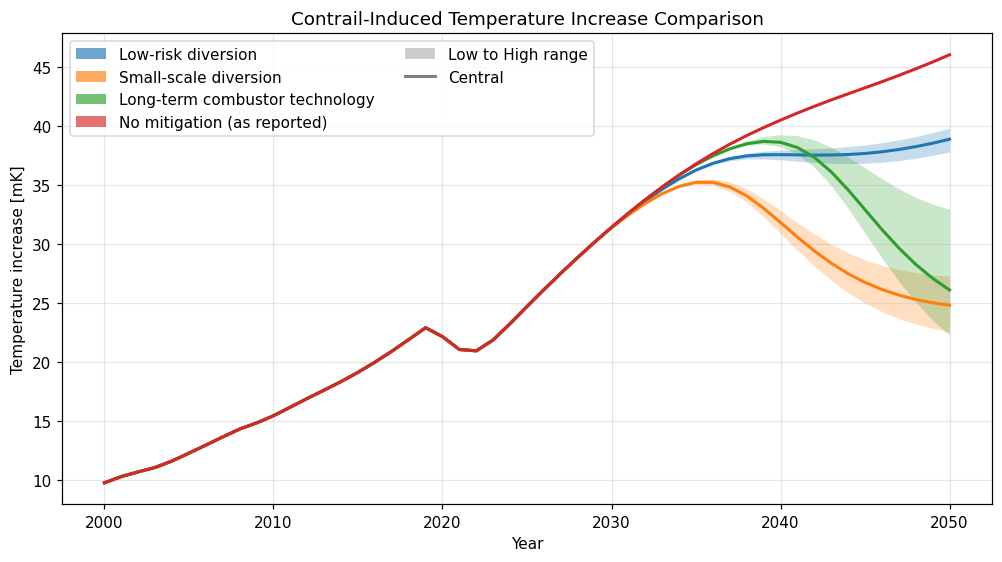

In [4]:
figure = assembly.plot("contrails_temperature_comparison",
                       scenario_groups=groups, group_display="envelope",
                       group_envelope_show_members=False,
                       group_envelope_middle=middle)
plt.savefig("fig5_contrails_temperature.pdf", bbox_inches="tight")
plt.show()

## Figure 2 — total aviation warming

The same variants seen through the total, which is what the reports' own
temperature statements refer to.

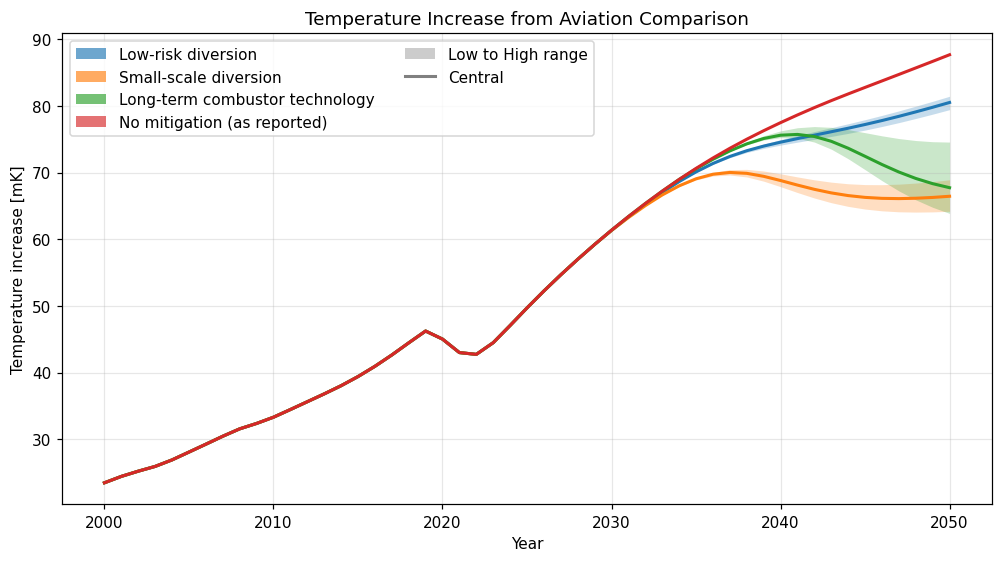

In [5]:
figure = assembly.plot("temperature_increase_comparison",
                       scenario_groups=groups, group_display="envelope",
                       group_envelope_show_members=False,
                       group_envelope_middle=middle)
plt.savefig("fig6_total_temperature.pdf", bbox_inches="tight")
plt.show()

## Figure 3 — the trade-off

Diversion buys contrail reduction by flying further, so it burns more fuel. This
is what the paper is actually about, and the reason `low-risk` exists as a
separate strategy: it accepts a much smaller contrail benefit in exchange for
adding no CO₂ at all.

The framework's absolute CO₂ comparison cannot show this — the penalty is
0.07 % of 2050 emissions, so all five scenarios draw on top of one another. The
trade-off needs its own axes: contrail warming avoided against CO₂ added.

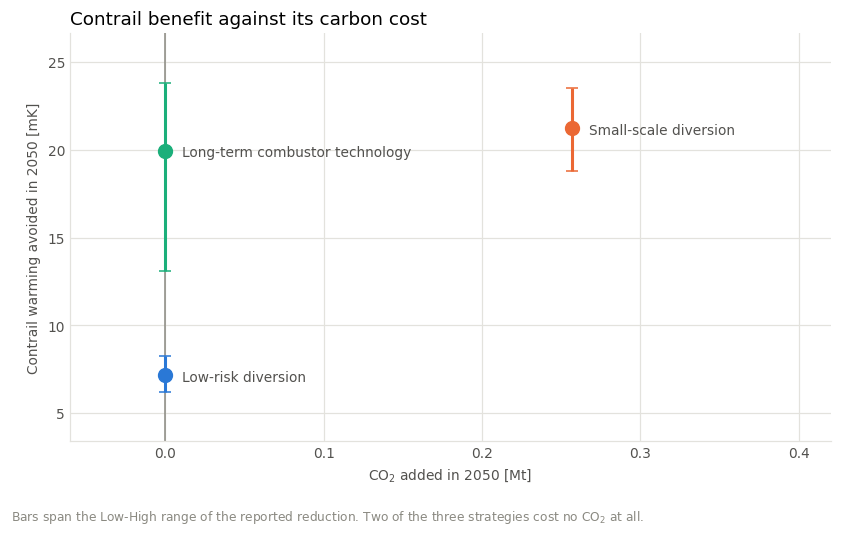

In [6]:
# The first three categorical slots -- blue, orange, aqua -- are the set that
# validates on the all-pairs pairlist a scatter needs.
FAMILY_COLORS = {
    "low_risk": "#2a78d6",
    "small_scale": "#eb6834",
    "long_term_tech": "#1baf7a",
}

def co2_2050(name):
    v = vectors[name]
    return v["co2_emissions_passenger"].loc[2050] + v["co2_emissions_freight"].loc[2050]

base_contrails = climate[BASELINE][T_CONTRAILS].loc[2050]
base_total = climate[BASELINE][T_TOTAL].loc[2050]
base_co2 = co2_2050(BASELINE)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
for key, family in families.items():
    central = variant_name(family["label"], "Central")
    avoided = 1000 * (base_contrails - climate[central][T_CONTRAILS].loc[2050])
    lo = 1000 * (base_contrails
                 - climate[variant_name(family["label"], "Low")][T_CONTRAILS].loc[2050])
    hi = 1000 * (base_contrails
                 - climate[variant_name(family["label"], "High")][T_CONTRAILS].loc[2050])
    added = co2_2050(central) - base_co2

    ax.errorbar(added, avoided, yerr=[[avoided - lo], [hi - avoided]],
                fmt="o", markersize=9, color=FAMILY_COLORS[key],
                ecolor=FAMILY_COLORS[key], elinewidth=2, capsize=4, zorder=3)
    ax.annotate(family["label"], (added, avoided), textcoords="offset points",
                xytext=(11, -4), fontsize=9, color=utils.INK_SECONDARY)

ax.axvline(0, color=utils.INK_MUTED, linewidth=1)
utils.style_axes(ax, "Contrail warming avoided in 2050 [mK]",
                 xlabel="CO$_2$ added in 2050 [Mt]")
ax.set_title("Contrail benefit against its carbon cost", loc="left")
ax.set_xlim(-0.06, 0.42)
ax.margins(y=0.16)
fig.text(0.0, -0.04,
         "Bars span the Low-High range of the reported reduction. Two of the "
         "three strategies cost no CO$_2$ at all.",
         fontsize=8, color=utils.INK_MUTED)
fig.tight_layout()
fig.savefig("fig7_contrail_tradeoff.pdf")
plt.show()

## Summary — what each strategy is worth in 2050

In [7]:
rows = []
for key, family in families.items():
    entry = {"strategy": family["label"]}
    for level in LEVELS:
        name = variant_name(family["label"], level)
        entry[f"contrail warming {level} [mK]"] = 1000 * climate[name][T_CONTRAILS].loc[2050]
    central = variant_name(family["label"], "Central")
    total = climate[central][T_TOTAL].loc[2050]
    co2 = (vectors[central]["co2_emissions_passenger"].loc[2050]
           + vectors[central]["co2_emissions_freight"].loc[2050])
    entry["total warming [mK]"] = 1000 * total
    entry["total reduction [%]"] = 100 * (1 - total / base_total)
    entry["CO2 penalty [%]"] = 100 * (co2 / base_co2 - 1)
    rows.append(entry)

summary = pd.DataFrame(rows).set_index("strategy")
print(f"baseline: contrail warming {1000 * base_contrails:.1f} mK, "
      f"total {1000 * base_total:.1f} mK, CO2 {base_co2:.1f} Mt\n")
display(summary.round(3))

baseline: contrail warming 46.1 mK, total 87.7 mK, CO2 386.1 Mt



,contrail warming Low [mK],contrail warming Central [mK],contrail warming High [mK],total warming [mK],total reduction [%],CO2 penalty [%]
strategy,,,,,,
Low-risk diversion,39.847,38.916,37.842,80.523,8.169,0.000
Small-scale diversion,27.312,24.841,22.584,66.451,24.218,0.066
Long-term combustor technology,32.973,26.130,22.273,67.737,22.751,0.000


In [8]:
# Every strategy must reduce contrail warming, and the combined case -- which
# contains both interventions -- must be the strongest.
base_2050 = climate[BASELINE][T_CONTRAILS].loc[2050]
central = {
    key: climate[variant_name(family["label"], "Central")][T_CONTRAILS].loc[2050]
    for key, family in families.items()
}
for key, value in central.items():
    assert value < base_2050, f"{key} does not reduce contrail warming"
assert central["small_scale"] < central["low_risk"], (
    "small-scale diversion is not stronger than the low-risk subset it contains"
)

for key, family in families.items():
    low = climate[variant_name(family["label"], "Low")][T_CONTRAILS]
    high = climate[variant_name(family["label"], "High")][T_CONTRAILS]
    # A larger reduction leaves less warming, so "High" must sit below "Low".
    assert (high.loc[2024:2050] <= low.loc[2024:2050] + 1e-12).all(), (
        f"{key}: the Low/High envelope crosses itself"
    )

print("PASS - every strategy reduces contrail warming, diversion strengthens "
      "with scope, and every envelope is well formed")

PASS - every strategy reduces contrail warming, diversion strengthens with scope, and every envelope is well formed


### Timing beats ultimate effectiveness on a 2050 horizon

The ordering of the two single interventions is not the ordering of their
headline numbers. Combustor technology is the stronger measure — 68.8 % against
59.3 % — yet by 2050 it leaves **more** contrail warming than small-scale
diversion does.

The reason is that temperature integrates forcing over time, and the technology
case starts five years later, so its logistic ramp is only ~67 % complete in
2050 while diversion has been fully deployed since ~2045. Measured as area under
the reduction curve over 2024–2050, diversion removes appreciably more
cumulative forcing despite the smaller endpoint.

This is worth stating plainly in the paper: **for contrails, a weaker measure
available sooner can outperform a stronger one that arrives later.** It also
means the result is sensitive to the assumed start years, which are a modelling
choice here rather than something Teoh et al. specify.

In [9]:
rows = []
for key in ("small_scale", "long_term_tech"):
    family = families[key]
    name = variant_name(family["label"], "Central")
    gain = vectors[name]["operations_contrails_gain"].loc[2024:2050]
    removed = (climate[BASELINE]["contrails_erf"].loc[2024:2050]
               - climate[name]["contrails_erf"].loc[2024:2050]).sum()
    rows.append({
        "strategy": family["label"],
        "start": int(family["levels"]["Central"]["operations_contrails_start_year"]),
        "final reduction [%]": family["levels"]["Central"]["operations_contrails_final_gain"],
        "reduction reached by 2050 [%]": gain.loc[2050],
        "cumulative ERF removed [W/m2-yr]": removed,
        "contrail warming 2050 [mK]": 1000 * climate[name][T_CONTRAILS].loc[2050],
    })
timing = pd.DataFrame(rows).set_index("strategy")
display(timing.round(3))

stronger = timing["final reduction [%]"].idxmax()
cooler = timing["contrail warming 2050 [mK]"].idxmin()
print(f"largest final reduction : {stronger}")
print(f"least warming in 2050   : {cooler}")
assert stronger != cooler, (
    "the timing effect has disappeared; the note above no longer applies"
)
print("\nPASS - the stronger measure is not the one that delivers most by 2050")

,start,final reduction [%],reduction reached by 2050 [%],cumulative ERF removed [W/m2-yr],contrail warming 2050 [mK]
strategy,,,,,
Small-scale diversion,2030,59.3,59.210,0.622,24.841
Long-term combustor technology,2035,68.8,67.424,0.452,26.130


largest final reduction : Long-term combustor technology
least warming in 2050   : Small-scale diversion

PASS - the stronger measure is not the one that delivers most by 2050


### The fuel penalty is real — and amplified by the SAF mandates

`low-risk` and `small-scale` start in the same year and differ only in how much
diverting they do, so the difference between them isolates the fuel penalty.

Two things to check. The **energy** increase should match the overconsumption
parameter exactly, confirming the penalty reaches fuel burn through
`energy_per_ask *= (1 + overconsumption / 100)`. The **CO₂** increase should
then be *larger* than that, because the SAF mandates in these scenarios are
quantity-based: the absolute SAF volumes are fixed, so any extra energy demand
is met entirely by fossil kerosene. The marginal fuel is the dirtiest one, and
the CO₂ penalty is scaled up by the ratio of kerosene's emission factor to the
2050 fleet-mean.

That amplification is a genuine result rather than an artefact, and it sharpens
the trade-off: under a quantity mandate, the CO₂ cost of contrail avoidance is
several times its fuel cost.

In [10]:
penalty_free = variant_name(families["low_risk"]["label"], "Central")
with_penalty = variant_name(families["small_scale"]["label"], "Central")

def totals(name):
    v = vectors[name]
    co2 = v["co2_emissions_passenger"].loc[2050] + v["co2_emissions_freight"].loc[2050]
    return co2, v["energy_consumption"].loc[2050]

co2_free, energy_free = totals(penalty_free)
co2_pen, energy_pen = totals(with_penalty)

parameter = vectors[with_penalty]["operations_contrails_overconsumption"].loc[2050]
energy_increase = 100 * (energy_pen / energy_free - 1)
co2_increase = 100 * (co2_pen / co2_free - 1)

print(f"overconsumption parameter at 2050 : {parameter:.6f} %")
print(f"observed energy increase          : {energy_increase:.6f} %")
print(f"observed CO2 increase             : {co2_increase:.6f} %")
print(f"amplification (CO2 / energy)      : {co2_increase / energy_increase:.2f}x")

# The energy penalty must match the parameter that drives it.
assert abs(energy_increase - parameter) < 1e-6, (
    "the contrail-avoidance fuel penalty does not reach energy consumption"
)
# ... and CO2 must rise by more, because the marginal fuel is fossil kerosene
# under a fixed-quantity SAF mandate.
assert co2_increase > energy_increase, (
    "the CO2 penalty is not amplified; the marginal fuel is no longer fossil"
)

kerosene_ef = vectors[with_penalty]["fossil_kerosene_co2_emission_factor"].loc[2050] \
    if "fossil_kerosene_co2_emission_factor" in vectors[with_penalty] else None
mean_ef = vectors[with_penalty]["co2_per_energy_mean"].loc[2050]
print(f"\nfleet-mean emission factor 2050   : {mean_ef:.2f} gCO2/MJ")
print(f"implied marginal emission factor  : "
      f"{mean_ef * co2_increase / energy_increase:.2f} gCO2/MJ  (kerosene is 88.7)")
print("\nPASS - the fuel penalty propagates, and the SAF mandate amplifies its CO2 cost")

overconsumption parameter at 2050 : 0.013979 %
observed energy increase          : 0.013979 %
observed CO2 increase             : 0.066488 %
amplification (CO2 / energy)      : 4.76x

fleet-mean emission factor 2050   : 18.66 gCO2/MJ
implied marginal emission factor  : 88.75 gCO2/MJ  (kerosene is 88.7)

PASS - the fuel penalty propagates, and the SAF mandate amplifies its CO2 cost
